# Walmart Store Sales Forecasting — ARIMA / SARIMA

In [1]:
%pip install -q seaborn mlflow dagshub statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)


CODE_PATHS = ["preprocessing.py", "evaluation.py"]

ARCH = "SARIMA"

C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)

Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

2026/07/09 16:45:36 INFO mlflow.tracking.fluent: Experiment with name 'SARIMA_Training' does not exist. Creating a new experiment.


MLflow experiment: SARIMA_Training


In [4]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)

train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [5]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")

🏃 View run SARIMA_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/cd221cae4e6e4a90b2654e4a86b43188
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
cleaning done


In [6]:
train_part, val_part, VAL_CUTOFF = ev.holdout_split(train_raw, val_weeks=13)
val_dates  = pd.date_range(VAL_CUTOFF + pd.Timedelta(weeks=1), TRAIN_END, freq="7D")
test_dates = pd.date_range(TEST_START, TEST_END, freq="7D")
print(f"train_part: {len(train_part)} rows (... {train_part.Date.max().date()})")
print(f"val_part  : {len(val_part)} rows ({val_part.Date.min().date()} ... {val_part.Date.max().date()})")
print("holiday weeks in val:", val_part.groupby('Date').IsHoliday.first().sum())

train_part: 383040 rows (... 2012-07-27)
val_part  : 38530 rows (2012-08-03 ... 2012-10-26)
holiday weeks in val: 1


## Stationarity, decomposition, ACF/PACF

ADF p-value: raw=0.0000 | diff(1)=0.0000 | diff(52)=0.0000


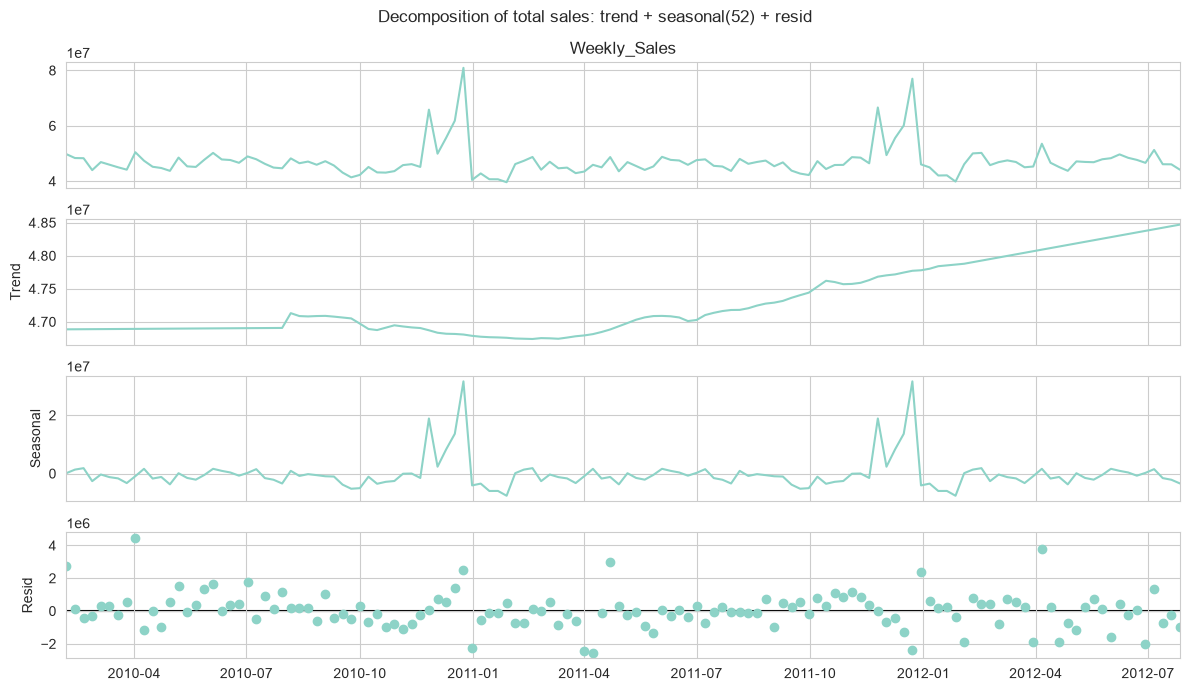

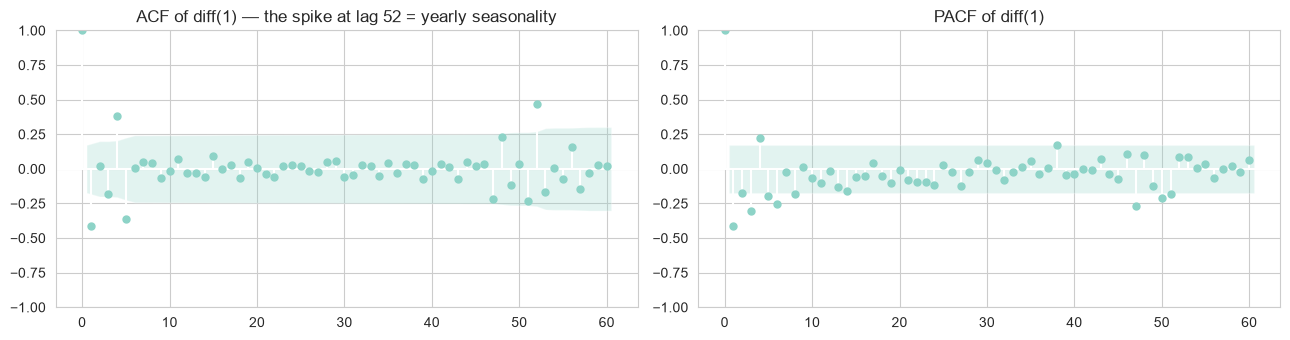

🏃 View run SARIMA_Stationarity at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/6ffd7e71bd184e5799fb04c692047f9f
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2


In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

total = train_part.groupby("Date").Weekly_Sales.sum()
total.index.freq = None

adf_raw   = adfuller(total)[1]
adf_diff1 = adfuller(total.diff().dropna())[1]
adf_sdiff = adfuller(total.diff(52).dropna())[1]
print(f"ADF p-value: raw={adf_raw:.4f} | diff(1)={adf_diff1:.4f} | diff(52)={adf_sdiff:.4f}")


dec = seasonal_decompose(total, period=52, model="additive", extrapolate_trend="freq")
fig = dec.plot(); fig.set_size_inches(12, 7)
plt.suptitle("Decomposition of total sales: trend + seasonal(52) + resid")
plt.tight_layout(); plt.savefig("pictures/sarima_decomposition.png", dpi=120); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(total.diff().dropna(), lags=60, ax=axes[0])
plot_pacf(total.diff().dropna(), lags=60, ax=axes[1], method="ywm")
axes[0].set_title("ACF of diff(1) — the spike at lag 52 = yearly seasonality")
axes[1].set_title("PACF of diff(1)")
plt.tight_layout(); plt.savefig("pictures/sarima_acf_pacf.png", dpi=120); plt.show()

with mlflow.start_run(run_name=f"{ARCH}_Stationarity"):
    mlflow.log_metrics({"adf_p_raw": adf_raw, "adf_p_diff1": adf_diff1,
                        "adf_p_seasonal_diff": adf_sdiff})
    for p in ["sarima_decomposition", "sarima_acf_pacf"]:
        mlflow.log_artifact(f"pictures/{p}.png")

## Order selection (AIC + validation) — SARIMA vs ARIMA+Fourier

In [8]:

def fourier_terms(dates, K, period=52.18):
    t = ((pd.to_datetime(dates) - TRAIN_START).days / 7.0).values
    X = {}
    for k in range(1, K + 1):
        X[f"cos{k}"] = np.cos(2 * np.pi * k * t / period)
        X[f"sin{k}"] = np.sin(2 * np.pi * k * t / period)
    return pd.DataFrame(X, index=dates)

val_total = val_part.groupby("Date").Weekly_Sales.sum()
val_hol = val_part.groupby("Date").IsHoliday.first()

candidates = {
    "SARIMA(1,1,1)x(0,1,1,52)": dict(order=(1, 1, 1), seasonal_order=(0, 1, 1, 52)),
    "ARIMA(1,1,1)+Fourier(K=4)": dict(order=(1, 1, 1), fourier_K=4),
    "ARIMA(1,1,1)+Fourier(K=8)": dict(order=(1, 1, 1), fourier_K=8),
    "ARIMA(2,1,2)+Fourier(K=8)": dict(order=(2, 1, 2), fourier_K=8),
}

def fit_forecast(y, fc_dates, order, seasonal_order=(0, 0, 0, 0), fourier_K=None):
    exog = fourier_terms(y.index, fourier_K) if fourier_K else None
    exog_f = fourier_terms(fc_dates, fourier_K) if fourier_K else None
    res = SARIMAX(y, order=order, seasonal_order=seasonal_order, exog=exog,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False)
    return res, np.asarray(res.forecast(len(fc_dates), exog=exog_f))

import re
with mlflow.start_run(run_name=f"{ARCH}_Order_Selection"):
    order_rows = []
    for name, kw in candidates.items():
        t0 = time.time()
        res, fc = fit_forecast(total, val_dates, **kw)
        s = wmae(val_total.values, fc, val_hol.values)
        order_rows.append({"config": name, "aic": res.aic, "val_wmae_total": s,
                           "fit_seconds": time.time() - t0})
        key = re.sub(r"[^0-9A-Za-z_]+", "_", name)
        mlflow.log_metric(f"aic_{key}", res.aic)
        mlflow.log_metric(f"total_wmae_{key}", s)
        print(f"{name:28s} AIC={res.aic:10.1f}  total-WMAE={s:12,.0f}  "
              f"({time.time()-t0:.1f}s)")
    order_df = pd.DataFrame(order_rows)
    mlflow.log_dict(order_df.to_dict("records"), "order_selection.json")

C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


SARIMA(1,1,1)x(0,1,1,52)     AIC=     741.9  total-WMAE=     726,641  (13.5s)


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


ARIMA(1,1,1)+Fourier(K=4)    AIC=    4277.0  total-WMAE=   1,304,222  (1.1s)


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,1,1)+Fourier(K=8)    AIC=    4248.4  total-WMAE=   1,525,860  (0.9s)


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2,1,2)+Fourier(K=8)    AIC=    4233.6  total-WMAE=   1,297,757  (1.9s)
🏃 View run SARIMA_Order_Selection at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/10042d739ca6418f930e987328d60eb2
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2


## store-level models + department-share disaggregation


In [9]:
shares_woy, shares_ov = prep.build_shares(train_part)
GLOBAL_MED = float(train_part.Weekly_Sales.median())
totals_tr = prep.store_totals(train_part)
totals_full = prep.store_totals(train_raw)
print("store totals:", totals_tr.shape, "| val weeks:", len(val_dates))

store totals: (130, 45) | val weeks: 13


In [10]:
RUN_FULL_SARIMA = True

def store_level_forecast(totals, fc_dates, **kw):
    preds = {}
    for s in totals.columns:
        try:
            _, fc = fit_forecast(totals[s], fc_dates, **kw)
        except Exception:
            fc = np.repeat(totals[s].tail(13).mean(), len(fc_dates))
        preds[s] = fc
    long = (pd.DataFrame(preds, index=fc_dates).rename_axis("Date")
            .reset_index().melt("Date", var_name="Store", value_name="store_pred"))
    long["Store"] = long.Store.astype(int)
    return long

store_configs = {
    "fourier_K4": dict(order=(1, 1, 1), fourier_K=4),
    "fourier_K8": dict(order=(1, 1, 1), fourier_K=8),
    "fourier_K8_212": dict(order=(2, 1, 2), fourier_K=8),
}
if RUN_FULL_SARIMA:
    store_configs["sarima_m52"] = dict(order=(1, 1, 1), seasonal_order=(0, 1, 1, 52))

results, store_fcs = {}, {}
for name, kw in store_configs.items():
    t0 = time.time()
    fc_long = store_level_forecast(totals_tr, val_dates, **kw)
    pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]], fc_long,
                             shares_woy, shares_ov, GLOBAL_MED)
    s = wmae(val_part.Weekly_Sales.values, pred, val_part.IsHoliday.values)
    results[name], store_fcs[name] = s, fc_long
    with mlflow.start_run(run_name=f"{ARCH}_StoreLevel_{name}"):
        mlflow.log_params({"config": name, **{k: str(v) for k, v in kw.items()}})
        mlflow.log_metric("val_wmae", s)
        mlflow.log_metric("fit_seconds", time.time() - t0)
    print(f"{name:16s} val WMAE = {s:10,.1f}   ({time.time()-t0:.0f}s)")

best_name = min(results, key=results.get)
best_kw = store_configs[best_name]
best_val_pred = prep.disaggregate(val_part[["Store", "Dept", "Date"]],
                                  store_fcs[best_name],
                                  shares_woy, shares_ov, GLOBAL_MED)
print("\nbest config:", best_name, "| val WMAE:", round(results[best_name], 1))

🏃 View run SARIMA_StoreLevel_fourier_K4 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/28a475476178491298220e1761129d98
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
fourier_K4       val WMAE =    1,674.5   (10s)
🏃 View run SARIMA_StoreLevel_fourier_K8 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/7457e4a32d3e4bd6b648170b23a9c877
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
fourier_K8       val WMAE =    1,639.3   (18s)


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


🏃 View run SARIMA_StoreLevel_fourier_K8_212 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/3f20a756a790424aa4f749a50a3dc53f
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
fourier_K8_212   val WMAE =    1,627.7   (28s)
🏃 View run SARIMA_StoreLevel_sarima_m52 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/a436248d764b4bc389e59a48956bc77d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
sarima_m52       val WMAE =    1,538.9   (533s)

best config: sarima_m52 | val WMAE: 1538.9


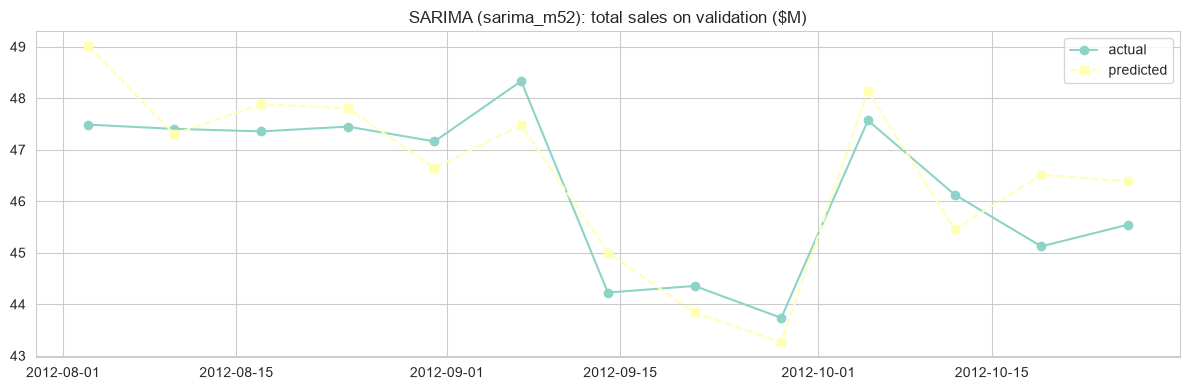

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
a = val_part.groupby("Date").Weekly_Sales.sum() / 1e6
p = pd.Series(best_val_pred, index=val_part.index).groupby(val_part.Date).sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({best_name}): total sales on validation ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()

## Final pipeline + submission

In [12]:
class StoreShareForecastPipeline(mlflow.pyfunc.PythonModel):


    def __init__(self, store_fc_long, shares_woy, shares_ov, global_med):
        self.store_fc_long = store_fc_long
        self.shares_woy = shares_woy
        self.shares_ov = shares_ov
        self.global_med = global_med

    def predict(self, context, model_input):
        df = model_input.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        return prep.disaggregate(df[["Store", "Dept", "Date"]], self.store_fc_long,
                                 self.shares_woy, self.shares_ov, self.global_med)

C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [13]:
REGISTER_AS_BEST = False


shares_woy_full, shares_ov_full = prep.build_shares(train_raw)
GLOBAL_MED_FULL = float(train_raw.Weekly_Sales.median())
store_fc_full = store_level_forecast(totals_full, test_dates, **best_kw)
wrapper = StoreShareForecastPipeline(store_fc_full, shares_woy_full,
                                     shares_ov_full, GLOBAL_MED_FULL)
test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({"config": best_name, "strategy": "store-level + dept-share"})
    mlflow.log_metric("val_wmae", results[best_name])
    if os.path.exists(f"pictures/{ARCH.lower()}_val_total.png"):
        mlflow.log_artifact(f"pictures/{ARCH.lower()}_val_total.png")
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")

2026/07/09 17:02:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/09 17:02:41 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run SARIMA_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2/runs/16528d07588a4cd49d5a9ed93250b6dc
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/2
pipeline logged, run_id = 16528d07588a4cd49d5a9ed93250b6dc
saved: submission_SARIMA.csv
